# (Optional) Colab Setup
If you aren't using Colab, you can delete the following code cell. This is just to help students with mounting to Google Drive to access the other .py files and downloading the data, which is a little trickier on Colab than on your local machine using Jupyter.

In [15]:
# you will be prompted with a window asking to grant permissions
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
# fill in the path in your Google Drive in the string below. Note: do not escape slashes or spaces
import os
datadir = "/content/assignment3"
!ls "/content/drive/My Drive/CS444/assignment3"
if not os.path.exists(datadir):
  !ln -s "/content/drive/My Drive/CS444/assignment3/" $datadir # TODO: Fill your assignment3 path
!pwd

'Copy of CS444 Assignment 3 Report (Spring 2025).gdoc'	 data   ResNet18_model.pth
ln: failed to create symbolic link '/content/assignment3': File exists


FileNotFoundError: [Errno 2] No such file or directory: '/content/assignment3'

# Data Setup

The first thing to do is implement a dataset class to load rotated CIFAR10 images with matching labels. Since there is already a CIFAR10 dataset class implemented in `torchvision`, we will extend this class and modify the `__get_item__` method appropriately to load rotated images.

Each rotation label should be an integer in the set {0, 1, 2, 3} which correspond to rotations of 0, 90, 180, or 270 degrees respectively.

In [13]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import random



In [ ]:
# This is in an external file
import os

if os.path.exists('dataset.py'):
    from dataset import *
else:
    def rotate_img(img, rot: int):
        if rot == 0: # 0 degrees rotation
            return img
        # TODO: Implement rotate_img() - return the rotated img
        elif rot == 1:  # 90 degrees rotation
            return torch.rot90(img, k=1, dims=[1, 2])
        elif rot == 2:  # 180 degrees rotation
            return torch.rot90(img, k=2, dims=[1, 2])
        elif rot == 3:  # 270 degrees rotation
            return torch.rot90(img, k=3, dims=[1, 2])
        else:
            raise ValueError('rotation should be 0, 90, 180, or 270 degrees')


    class CIFAR10Rotation(torchvision.datasets.CIFAR10):

        def __init__(self, root, train, download, transform) -> None:
            super().__init__(root=root, train=train, download=download, transform=transform)

        def __len__(self):
            return len(self.data)

        def __getitem__(self, index: int):
            image, cls_label = super().__getitem__(index)

            # randomly select image rotation
            rotation_label = random.choice([0, 1, 2, 3])
            image_rotated = rotate_img(image, rotation_label)

            rotation_label = torch.tensor(rotation_label).long()
            return image, image_rotated, rotation_label, torch.tensor(cls_label).long()


    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])

    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])

    batch_size = 128

    trainset = CIFAR10Rotation(root='./data', train=True,
                                            download=True, transform=transform_train)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                              shuffle=True, num_workers=0)

    testset = CIFAR10Rotation(root='./data', train=False,
                                           download=True, transform=transform_test)
    testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                             shuffle=False, num_workers=0)

Files already downloaded and verified
Files already downloaded and verified


Show some example images and rotated images with labels:

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


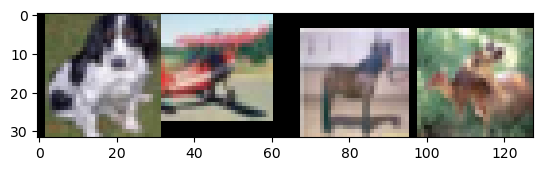

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Class labels:  dog   plane horse deer 


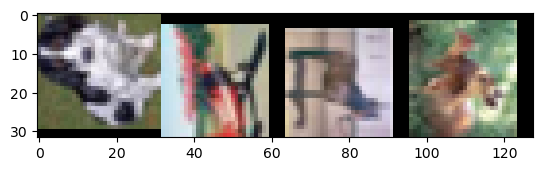

Rotation labels:  90    90    270   270  


In [ ]:

import matplotlib.pyplot as plt

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

rot_classes = ('0', '90', '180', '270')


def imshow(img):
    # unnormalize
    img = transforms.Normalize((0, 0, 0), (1/0.2023, 1/0.1994, 1/0.2010))(img)
    img = transforms.Normalize((-0.4914, -0.4822, -0.4465), (1, 1, 1))(img)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


dataiter = iter(trainloader)
images, rot_images, rot_labels, labels = next(dataiter)

# print images and rotated images
img_grid = imshow(torchvision.utils.make_grid(images[:4], padding=0))
print('Class labels: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))
img_grid = imshow(torchvision.utils.make_grid(rot_images[:4], padding=0))
print('Rotation labels: ', ' '.join(f'{rot_classes[rot_labels[j]]:5s}' for j in range(4)))

# Evaluation code

In [ ]:
import time

def run_test(net, testloader, criterion, task):
    correct = 0
    total = 0
    avg_test_loss = 0.0
    # since we're not training, we don't need to calculate the gradients for our outputs
    with torch.no_grad():
        for images, images_rotated, labels, cls_labels in testloader:
            if task == 'rotation':
              images, labels = images_rotated.to(device), labels.to(device)
            elif task == 'classification':
              images, labels = images.to(device), cls_labels.to(device)
            # TODO: Calculate outputs by running images through the network
            # The class with the highest energy is what we choose as prediction

            outputs = net(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # loss
            avg_test_loss += criterion(outputs, labels)  / len(testloader)
    print('TESTING:')
    print(f'Accuracy of the network on the 10000 test images: {100 * correct / total:.2f} %')
    print(f'Average loss on the 10000 test images: {avg_test_loss:.3f}')

In [ ]:
def adjust_learning_rate(optimizer, epoch, init_lr, decay_epochs=30):
    """Sets the learning rate to the initial LR decayed by 10 every 30 epochs"""
    lr = init_lr * (0.1 ** (epoch // decay_epochs))
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

# 1. Train a ResNet18 on the rotation task

In this section, we will train a ResNet18 model on the rotation task. The input is a rotated image and the model predicts the rotation label. See the Data Setup section for details.

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import resnet18

net = resnet18(num_classes=4)
net = net.to(device)

In [ ]:
import torch.optim as optim

# TODO: Define criterion and optimizer

criterion = nn.CrossEntropyLoss()
# optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
optimizer = optim.Adam(net.parameters(), lr=0.001)

In [ ]:
# Both the self-supervised rotation task and supervised CIFAR10 classification are
# trained with the CrossEntropyLoss, so we can use the training loop code.

def train(net, criterion, optimizer, num_epochs, decay_epochs, init_lr, task):

    for epoch in range(num_epochs):  # loop over the dataset multiple times

        running_loss = 0.0
        running_correct = 0.0
        running_total = 0.0
        start_time = time.time()
        epoch_start_time = time.time()

        net.to(device)

        net.train()

        for i, (imgs, imgs_rotated, rotation_label, cls_label) in enumerate(trainloader, 0):
            adjust_learning_rate(optimizer, epoch, init_lr, decay_epochs)

            # TODO: Set the data to the correct device; Different task will use different inputs and labels
            #
            if task == 'rotation':
                images, labels = imgs_rotated.to(device), rotation_label.to(device)
            elif task == 'classification':
                images, labels = imgs.to(device), cls_label.to(device)

            # TODO: Zero the parameter gradients
            #
            optimizer.zero_grad()

            # TODO: forward + backward + optimize
            #
            outputs = net(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # TODO: Get predicted results
            predicted = torch.max(outputs.data, 1)[1]

            # print statistics
            print_freq = 100
            running_loss += loss.item()

            # calc acc
            running_total += labels.size(0)
            running_correct += (predicted == labels).sum().item()

            if i % print_freq == (print_freq - 1):    # print every 2000 mini-batches
                print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / print_freq:.3f} acc: {100*running_correct / running_total:.2f} time: {time.time() - start_time:.2f}')
                running_loss, running_correct, running_total = 0.0, 0.0, 0.0
                start_time = time.time()

        # TODO: Run the run_test() function after each epoch; Set the model to the evaluation mode.
        net.eval()
        run_test(net, testloader, criterion, task)
        print('Time taken for epoch %d: %.2f' % (epoch + 1, time.time() - epoch_start_time))
    print('Finished Training')


In [ ]:
train(net, criterion, optimizer, num_epochs=45, decay_epochs=15, init_lr=0.01, task='rotation')

# TODO: Save the model
MODEL_PATH = './rotation_model.pth'
torch.save(net.state_dict(), MODEL_PATH)

[1,   100] loss: 1.467 acc: 36.19 time: 3.33
[1,   200] loss: 1.216 acc: 45.79 time: 2.51
[1,   300] loss: 1.158 acc: 48.91 time: 2.45
TESTING:
Accuracy of the network on the 10000 test images: 47.59 %
Average loss on the 10000 test images: 1.355
Time taken for epoch 1: 12.62
[2,   100] loss: 1.146 acc: 50.16 time: 3.09
[2,   200] loss: 1.131 acc: 50.46 time: 2.49
[2,   300] loss: 1.086 acc: 53.00 time: 2.48
TESTING:
Accuracy of the network on the 10000 test images: 54.60 %
Average loss on the 10000 test images: 1.060
Time taken for epoch 2: 12.10
[3,   100] loss: 1.072 acc: 53.89 time: 2.97
[3,   200] loss: 1.028 acc: 56.59 time: 2.40
[3,   300] loss: 1.034 acc: 56.02 time: 2.49
TESTING:
Accuracy of the network on the 10000 test images: 58.89 %
Average loss on the 10000 test images: 0.989
Time taken for epoch 3: 12.10
[4,   100] loss: 1.007 acc: 56.71 time: 2.96
[4,   200] loss: 0.994 acc: 57.77 time: 2.47
[4,   300] loss: 0.984 acc: 58.33 time: 2.44
TESTING:
Accuracy of the network o

# 2.1 Fine-tuning on the pre-trained model

In this section, we will load the pre-trained ResNet18 model and fine-tune on the classification task. We will freeze all previous layers except for the 'layer4' block and 'fc' layer.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import resnet18
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

# TODO: Load the pre-trained ResNet18 model
MODEL_PATH = './rotation_model.pth'

net = resnet18(num_classes=4)
net = net.to(device)
net.load_state_dict(torch.load(MODEL_PATH))


# Not sure if this is needed. IT IS NEEDED
num_ftrs = net.fc.in_features
net.fc = nn.Linear(num_ftrs, len(classes))
net = net.to(device)


In [ ]:
# TODO: Freeze all previous layers; only keep the 'layer4' block and 'fc' layer trainable
for param in net.parameters():
    param.requires_grad = False
for param in net.layer4.parameters():
    param.requires_grad = True
for param in net.fc.parameters():
    param.requires_grad = True


In [ ]:
# Print all the trainable parameters
params_to_update = net.parameters()
print("Params to learn:")
params_to_update = []
for name,param in net.named_parameters():
    if param.requires_grad == True:
        params_to_update.append(param)
        print("\t",name)

Params to learn:
	 layer4.0.conv1.weight
	 layer4.0.bn1.weight
	 layer4.0.bn1.bias
	 layer4.0.conv2.weight
	 layer4.0.bn2.weight
	 layer4.0.bn2.bias
	 layer4.0.downsample.0.weight
	 layer4.0.downsample.1.weight
	 layer4.0.downsample.1.bias
	 layer4.1.conv1.weight
	 layer4.1.bn1.weight
	 layer4.1.bn1.bias
	 layer4.1.conv2.weight
	 layer4.1.bn2.weight
	 layer4.1.bn2.bias
	 fc.weight
	 fc.bias


In [ ]:
# TODO: Define criterion and optimizer
# Note that your optimizer only needs to update the parameters that are trainable.
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
# optimizer = optim.Adam(net.parameters(), lr=0.001)

In [ ]:
train(net, criterion, optimizer, num_epochs=20, decay_epochs=10, init_lr=0.01, task='classification')

# Save the model
MODEL_PATH = './classification_model-2-1_SGD.pth'

torch.save(net.state_dict(), MODEL_PATH)

[1,   100] loss: 2.191 acc: 17.67 time: 2.74
[1,   200] loss: 2.138 acc: 19.46 time: 2.22
[1,   300] loss: 2.124 acc: 19.87 time: 2.19
TESTING:
Accuracy of the network on the 10000 test images: 21.69 %
Average loss on the 10000 test images: 2.095
Time taken for epoch 1: 10.98
[2,   100] loss: 2.089 acc: 21.38 time: 2.86
[2,   200] loss: 2.084 acc: 21.62 time: 2.15
[2,   300] loss: 2.082 acc: 22.11 time: 2.25
TESTING:
Accuracy of the network on the 10000 test images: 23.05 %
Average loss on the 10000 test images: 2.041
Time taken for epoch 2: 11.10
[3,   100] loss: 2.051 acc: 23.02 time: 2.86
[3,   200] loss: 2.040 acc: 23.76 time: 2.23
[3,   300] loss: 2.031 acc: 24.41 time: 2.18
TESTING:
Accuracy of the network on the 10000 test images: 25.99 %
Average loss on the 10000 test images: 1.986
Time taken for epoch 3: 11.10
[4,   100] loss: 2.003 acc: 25.32 time: 2.85
[4,   200] loss: 1.974 acc: 26.69 time: 2.25
[4,   300] loss: 1.957 acc: 27.52 time: 2.25
TESTING:
Accuracy of the network o

# 2.2 Fine-tuning on the randomly initialized model
In this section, we will randomly initialize a ResNet18 model and fine-tune on the classification task. We will freeze all previous layers except for the 'layer4' block and 'fc' layer.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import resnet18

# TODO: Randomly initialize a ResNet18 model

net = resnet18(num_classes=len(classes))
net = net.to(device)
device

'cuda'

In [ ]:
# TODO: Freeze all previous layers; only keep the 'layer4' block and 'fc' layer trainable
# To do this, you should set requires_grad=False for the frozen layers.

for param in net.parameters():
    param.requires_grad = False
for param in net.layer4.parameters():
    param.requires_grad = True
for param in net.fc.parameters():
    param.requires_grad = True


In [ ]:
# Print all the trainable parameters
params_to_update = net.parameters()
print("Params to learn:")
params_to_update = []
for name,param in net.named_parameters():
    if param.requires_grad == True:
        params_to_update.append(param)
        print("\t",name)

Params to learn:
	 layer4.0.conv1.weight
	 layer4.0.bn1.weight
	 layer4.0.bn1.bias
	 layer4.0.conv2.weight
	 layer4.0.bn2.weight
	 layer4.0.bn2.bias
	 layer4.0.downsample.0.weight
	 layer4.0.downsample.1.weight
	 layer4.0.downsample.1.bias
	 layer4.1.conv1.weight
	 layer4.1.bn1.weight
	 layer4.1.bn1.bias
	 layer4.1.conv2.weight
	 layer4.1.bn2.weight
	 layer4.1.bn2.bias
	 fc.weight
	 fc.bias


In [ ]:
import torch.optim as optim

# TODO: Define criterion and optimizer
# Note that your optimizer only needs to update the parameters that are trainable.
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(params_to_update, lr=0.01, momentum=0.9, weight_decay=5e-4)
# optimizer = optim.Adam(net.parameters(), lr=0.001)

In [ ]:
train(net, criterion, optimizer, num_epochs=20, decay_epochs=10, init_lr=0.01, task='classification')

# Save the model
MODEL_PATH = './classification_model-2-2.pth'
torch.save(net.state_dict(), MODEL_PATH)

[1,   100] loss: 2.117 acc: 24.37 time: 2.85
[1,   200] loss: 1.967 acc: 29.60 time: 2.27
[1,   300] loss: 1.936 acc: 30.89 time: 2.26
TESTING:
Accuracy of the network on the 10000 test images: 33.44 %
Average loss on the 10000 test images: 1.895
Time taken for epoch 1: 11.36
[2,   100] loss: 1.859 acc: 33.08 time: 2.91
[2,   200] loss: 1.873 acc: 33.13 time: 2.23
[2,   300] loss: 1.819 acc: 34.51 time: 2.22
TESTING:
Accuracy of the network on the 10000 test images: 36.47 %
Average loss on the 10000 test images: 1.773
Time taken for epoch 2: 11.26
[3,   100] loss: 1.808 acc: 35.35 time: 2.84
[3,   200] loss: 1.813 acc: 34.59 time: 2.24
[3,   300] loss: 1.790 acc: 35.57 time: 2.25
TESTING:
Accuracy of the network on the 10000 test images: 38.65 %
Average loss on the 10000 test images: 1.725
Time taken for epoch 3: 11.31
[4,   100] loss: 1.762 acc: 35.87 time: 2.86
[4,   200] loss: 1.769 acc: 36.26 time: 2.28
[4,   300] loss: 1.759 acc: 36.69 time: 2.29
TESTING:
Accuracy of the network o

# 3.1 Supervised training on the pre-trained model
In this section, we will load the pre-trained ResNet18 model and re-train the whole model on the classification task.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import resnet18

# TODO: Load the pre-trained ResNet18 model

MODEL_PATH = './rotation_model.pth'
net = resnet18(num_classes=4)
net = net.to(device)
state_dict = torch.load(MODEL_PATH)
net.load_state_dict(state_dict)

num_ftrs = net.fc.in_features
net.fc = nn.Linear(num_ftrs, len(classes))

In [ ]:
import torch.optim as optim


# TODO: Define criterion and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
# optimizer = optim.Adam(net.parameters(), lr=0.001, weight_decay=5e-4)

In [ ]:
train(net, criterion, optimizer, num_epochs=20, decay_epochs=10, init_lr=0.01, task='classification')

# Save the model
MODEL_PATH = './classification_model-3-1.pth'
torch.save(net.state_dict(), MODEL_PATH)

[1,   100] loss: 2.168 acc: 17.38 time: 2.95
[1,   200] loss: 2.035 acc: 21.66 time: 2.45
[1,   300] loss: 1.960 acc: 23.91 time: 2.35
TESTING:
Accuracy of the network on the 10000 test images: 26.83 %
Average loss on the 10000 test images: 1.854
Time taken for epoch 1: 12.07
[2,   100] loss: 1.850 acc: 27.09 time: 2.99
[2,   200] loss: 1.818 acc: 28.78 time: 2.40
[2,   300] loss: 1.786 acc: 30.84 time: 2.44
TESTING:
Accuracy of the network on the 10000 test images: 33.87 %
Average loss on the 10000 test images: 1.699
Time taken for epoch 2: 11.87
[3,   100] loss: 1.714 acc: 33.71 time: 3.02
[3,   200] loss: 1.674 acc: 35.47 time: 2.39
[3,   300] loss: 1.673 acc: 35.86 time: 2.48
TESTING:
Accuracy of the network on the 10000 test images: 39.11 %
Average loss on the 10000 test images: 1.592
Time taken for epoch 3: 11.83
[4,   100] loss: 1.607 acc: 38.62 time: 3.04
[4,   200] loss: 1.617 acc: 37.91 time: 2.33
[4,   300] loss: 1.589 acc: 39.14 time: 2.39
TESTING:
Accuracy of the network o

# 3.2 Supervised training on the randomly initialized model
In this section, we will randomly initialize a ResNet18 model and re-train the whole model on the classification task.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import resnet18

# TODO: Randomly initialize a ResNet18 model
net = resnet18(num_classes=len(classes)).to(device)
device

'cuda'

In [ ]:
# TODO: Define criterion and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
# optimizer = optim.Adam(net.parameters(), lr=0.001, weight_decay=5e-4)

In [ ]:
train(net, criterion, optimizer, num_epochs=20, decay_epochs=10, init_lr=0.01, task='classification')

# Save the model
MODEL_PATH = './classification_model-3-2.pth'

[1,   100] loss: 2.026 acc: 27.99 time: 3.15
[1,   200] loss: 1.692 acc: 38.52 time: 2.51
[1,   300] loss: 1.560 acc: 43.41 time: 2.46
TESTING:
Accuracy of the network on the 10000 test images: 49.09 %
Average loss on the 10000 test images: 1.390
Time taken for epoch 1: 12.26
[2,   100] loss: 1.417 acc: 48.62 time: 2.97
[2,   200] loss: 1.355 acc: 51.79 time: 2.42
[2,   300] loss: 1.312 acc: 52.13 time: 2.49
TESTING:
Accuracy of the network on the 10000 test images: 58.43 %
Average loss on the 10000 test images: 1.172
Time taken for epoch 2: 12.24
[3,   100] loss: 1.217 acc: 56.30 time: 3.08
[3,   200] loss: 1.170 acc: 58.05 time: 2.55
[3,   300] loss: 1.119 acc: 60.17 time: 2.45
TESTING:
Accuracy of the network on the 10000 test images: 63.12 %
Average loss on the 10000 test images: 1.041
Time taken for epoch 3: 12.23
[4,   100] loss: 1.067 acc: 62.02 time: 3.02
[4,   200] loss: 1.052 acc: 62.94 time: 2.47
[4,   300] loss: 1.024 acc: 63.63 time: 2.40
TESTING:
Accuracy of the network o

# Section 4

Change the architecture to a ResNet50

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

from torchvision.models import resnet50
from torchvision.models import resnet101

net = resnet101(num_classes=4)
net = net.to(device)

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
# optimizer = optim.Adam(net.parameters(), lr=0.001, weight_decay=5e-4)

In [ ]:
train(net, criterion, optimizer, num_epochs=200, decay_epochs=100, init_lr=0.01, task='rotation')

MODEL_PATH = './rotation_model_resnet101_SGD.pth'
torch.save(net.state_dict(), MODEL_PATH)


[1,   100] loss: 2.674 acc: 28.25 time: 4.70
[1,   200] loss: 2.094 acc: 37.26 time: 4.02
[1,   300] loss: 2.032 acc: 36.37 time: 4.16
TESTING:
Accuracy of the network on the 10000 test images: 38.59 %
Average loss on the 10000 test images: 51.449
Time taken for epoch 1: 19.15
[2,   100] loss: 1.816 acc: 39.64 time: 4.40
[2,   200] loss: 1.570 acc: 41.78 time: 4.00
[2,   300] loss: 1.794 acc: 40.75 time: 3.97
TESTING:
Accuracy of the network on the 10000 test images: 48.17 %
Average loss on the 10000 test images: 1.176
Time taken for epoch 2: 18.44
[3,   100] loss: 1.653 acc: 43.66 time: 4.80
[3,   200] loss: 1.649 acc: 44.61 time: 4.01
[3,   300] loss: 1.597 acc: 43.71 time: 4.06
TESTING:
Accuracy of the network on the 10000 test images: 47.92 %
Average loss on the 10000 test images: 1.235
Time taken for epoch 3: 18.99
[4,   100] loss: 1.587 acc: 41.30 time: 4.74
[4,   200] loss: 1.639 acc: 39.99 time: 4.24
[4,   300] loss: 1.614 acc: 34.86 time: 4.08
TESTING:
Accuracy of the network 

From this: rotation_model_resnet50, train the full network on the supervised CIFAR10 classification task.

From random weights, train the full network on the supervised CIFAR10 classification task

## 4 3.1

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import resnet50
from torchvision.models import resnet101

MODEL_PATH = './rotation_model_resnet101_SGD.pth'
net = resnet101(num_classes=4)
net = net.to(device)
state_dict = torch.load(MODEL_PATH)
net.load_state_dict(state_dict)

num_ftrs = net.fc.in_features
net.fc = nn.Linear(num_ftrs, len(classes))

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9)
# optimizer = optim.Adam(net.parameters(), lr=0.001)

In [ ]:
train(net, criterion, optimizer, num_epochs=40, decay_epochs=10, init_lr=0.01, task='classification')

# Save the model
MODEL_PATH = './classification_model-4-3-1_resnet101_SGD.pth'
torch.save(net.state_dict(), MODEL_PATH)

[1,   100] loss: 1.383 acc: 52.13 time: 4.62
[1,   200] loss: 1.059 acc: 63.46 time: 3.95
[1,   300] loss: 0.980 acc: 65.81 time: 4.13
TESTING:
Accuracy of the network on the 10000 test images: 66.55 %
Average loss on the 10000 test images: 0.986
Time taken for epoch 1: 18.96
[2,   100] loss: 0.880 acc: 69.30 time: 4.90
[2,   200] loss: 0.862 acc: 70.28 time: 4.07
[2,   300] loss: 0.837 acc: 71.23 time: 3.95
TESTING:
Accuracy of the network on the 10000 test images: 73.35 %
Average loss on the 10000 test images: 0.772
Time taken for epoch 2: 18.92
[3,   100] loss: 0.777 acc: 73.39 time: 4.66
[3,   200] loss: 0.769 acc: 72.97 time: 4.10
[3,   300] loss: 0.755 acc: 73.71 time: 3.96
TESTING:
Accuracy of the network on the 10000 test images: 75.15 %
Average loss on the 10000 test images: 0.720
Time taken for epoch 3: 18.68
[4,   100] loss: 0.706 acc: 75.70 time: 4.62
[4,   200] loss: 0.706 acc: 75.45 time: 3.87
[4,   300] loss: 0.713 acc: 75.41 time: 3.85
TESTING:
Accuracy of the network o

# Extra Credit

In [1]:
import torch
from torchvision import transforms, datasets
from PIL import Image
import torch.nn.functional as F

from torchvision.models import resnet18, resnet50, resnet101
import torch
import random

import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms

device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
device

'mps'

In [ ]:

!curl -L https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-160.tgz -o imagenette2-160.tgz
!tar -xzvf imagenette2-160.tgz

In [2]:
import os
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Custom Dataset using the CSV file
class NoisyImagenetteDataset(Dataset):
    def __init__(self, csv_file, data_dir, transform=None, label_column='noisy_labels_0'):
        self.data = pd.read_csv(csv_file)
        self.data_dir = data_dir
        self.transform = transform
        self.label_column = label_column

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        # Construct full image path; note that CSV 'path' is relative
        img_path = os.path.join(self.data_dir, row['path'])
        image = Image.open(img_path).convert("RGB")
        label = row[self.label_column]
        if self.transform:
            image = self.transform(image)
        return image, label

# Set paths
csv_path = 'imagenette2-160/noisy_imagenette.csv'
# Assuming images reside under the same parent folder as the CSV (e.g. train subfolder)
data_dir = os.path.join(os.path.dirname(csv_path))

# Define transforms
transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor()
])

# Create dataset and DataLoader
dataset = NoisyImagenetteDataset(csv_file=csv_path, data_dir=data_dir, transform=transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)


In [3]:
def rotate_img(img, rot: int):
    if rot == 0:  # 0 degrees rotation
        return img
    elif rot == 1:  # 90 degrees rotation
        return transforms.functional.rotate(img, 90)
    elif rot == 2:  # 180 degrees rotation
        return transforms.functional.rotate(img, 180)
    elif rot == 3:  # 270 degrees rotation
        return transforms.functional.rotate(img, 270)
    else:
        raise ValueError('rotation should be 0, 90, 180, or 270 degrees')

class NoisyImagenetteRotation(NoisyImagenetteDataset):
    # ...existing code from NoisyImagenetteDataset...
    def __getitem__(self, idx):
        image, label = super().__getitem__(idx)
        rotation_label = random.choice([0, 1, 2, 3])
        image_rotated = rotate_img(image, rotation_label)
        rotation_label = torch.tensor(rotation_label).long()
        return image, image_rotated, rotation_label, label

In [4]:
# Define transforms for rotation training
transform_rc = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor()
])
# Reuse csv_path and data_dir defined earlier
dataset_rot = NoisyImagenetteRotation(csv_file=csv_path, data_dir=data_dir, transform=transform_rc)
trainloader_img = DataLoader(dataset_rot, batch_size=32, shuffle=True)

# Create and send model to device
from torchvision.models import resnet18, resnet50
import torch.nn as nn
import torch.optim as optim

net_img = resnet18(num_classes=4)
net_img = net_img.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net_img.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

def train_rotation(net, criterion, optimizer, num_epochs=5):
    net.train()
    for epoch in range(num_epochs):
        for i, (orig, rotated, rot_label, _) in enumerate(trainloader_img):
            orig = orig.to(device)
            rotated = rotated.to(device)
            rot_label = rot_label.to(device)
            optimizer.zero_grad()
            outputs = net(rotated)
            loss = criterion(outputs, rot_label)
            loss.backward()
            optimizer.step()
            if i % 50 == 0:
                print(f'Epoch {epoch+1}, Step {i}, Loss: {loss.item():.3f}, acc: {100 * (outputs.argmax(1) == rot_label).float().mean():.2f}%')
    if epoch % 10 == 0:
          # Save the model
          model_path = f'./rotation_model_imagenette_{epoch}.pth'
          torch.save(net.state_dict(), model_path)
                

    print('Finished rotation training.')


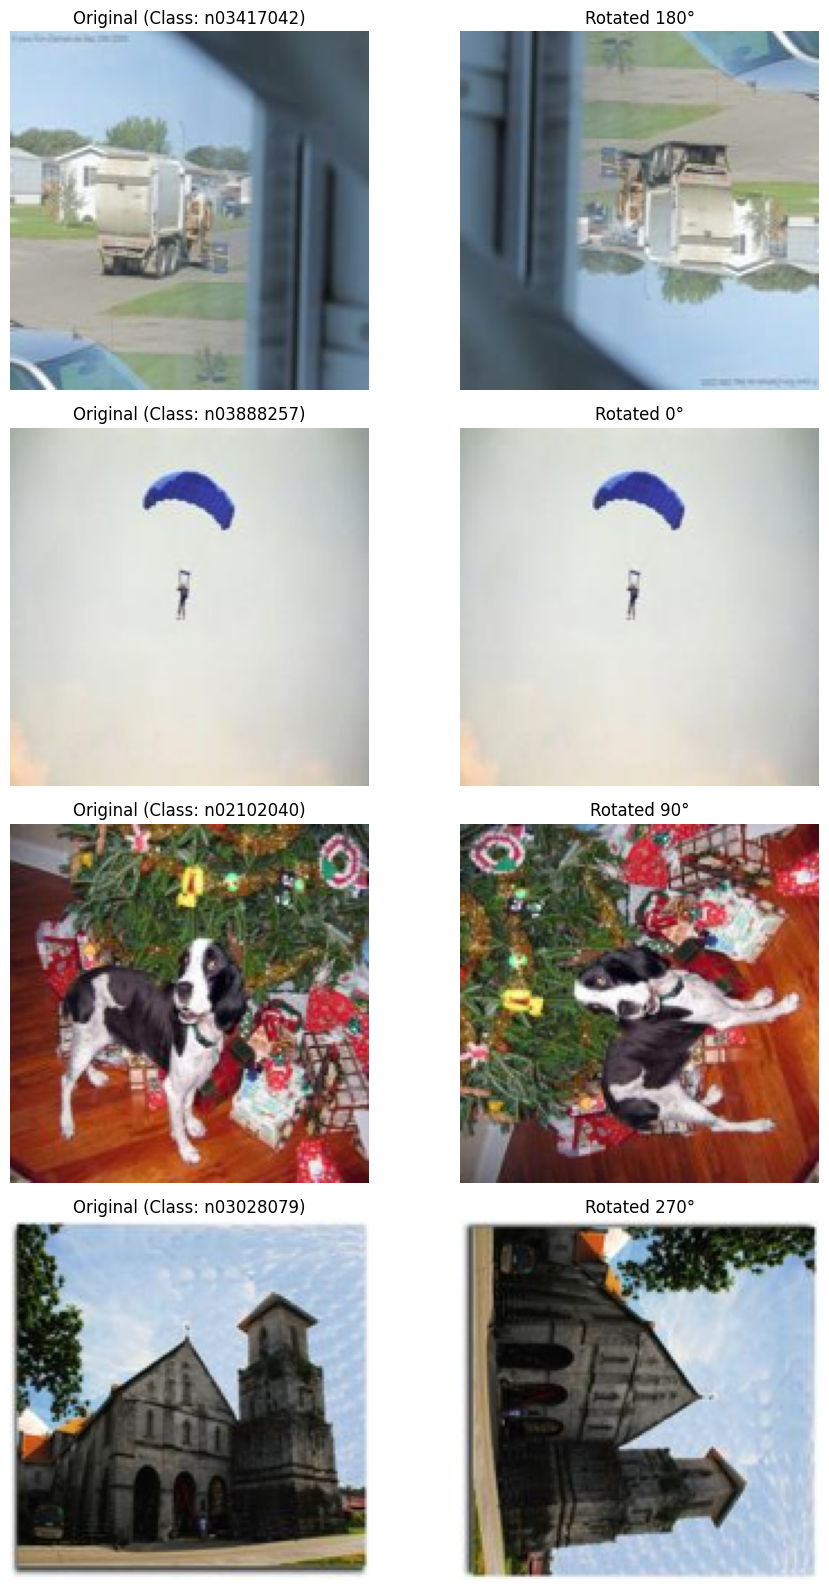

In [5]:
import matplotlib.pyplot as plt

def show_samples():
    # Get a batch from the dataset
    dataiter = iter(trainloader_img)
    images, rotated_images, rotation_labels, class_labels = next(dataiter)

    # Convert tensors to numpy arrays for display
    # Reshape from [batch, channels, height, width] to [batch, height, width, channels]
    images = images.permute(0, 2, 3, 1).cpu().numpy()
    rotated_images = rotated_images.permute(0, 2, 3, 1).cpu().numpy()

    # Create a figure to display samples
    fig, axes = plt.subplots(4, 2, figsize=(10, 16))

    rot_names = ['0°', '90°', '180°', '270°']

    for i in range(4):
        # Display original image
        axes[i, 0].imshow(images[i])
        axes[i, 0].set_title(f"Original (Class: {class_labels[i]})")
        axes[i, 0].axis('off')

        # Display rotated image
        axes[i, 1].imshow(rotated_images[i])
        axes[i, 1].set_title(f"Rotated {rot_names[rotation_labels[i]]}")
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

show_samples()

In [11]:
train_rotation(net_img, criterion, optimizer, num_epochs=45)

# Save the model
MODEL_PATH = './rotation_model_imagenette_18_45.pth'
torch.save(net_img.state_dict(), MODEL_PATH)


Epoch 1, Step 0, Loss: 1.504, acc: 12.50%
Epoch 1, Step 50, Loss: 1.732, acc: 28.12%
Epoch 1, Step 100, Loss: 1.378, acc: 28.12%
Epoch 1, Step 150, Loss: 1.214, acc: 46.88%
Epoch 1, Step 200, Loss: 1.207, acc: 50.00%
Epoch 1, Step 250, Loss: 1.284, acc: 34.38%
Epoch 1, Step 300, Loss: 1.403, acc: 40.62%
Epoch 1, Step 350, Loss: 1.218, acc: 37.50%
Epoch 1, Step 400, Loss: 1.128, acc: 59.38%
Epoch 2, Step 0, Loss: 1.284, acc: 53.12%
Epoch 2, Step 50, Loss: 1.556, acc: 25.00%
Epoch 2, Step 100, Loss: 1.364, acc: 31.25%
Epoch 2, Step 150, Loss: 1.283, acc: 34.38%
Epoch 2, Step 200, Loss: 1.078, acc: 56.25%
Epoch 2, Step 250, Loss: 1.257, acc: 40.62%
Epoch 2, Step 300, Loss: 1.139, acc: 50.00%
Epoch 2, Step 350, Loss: 1.315, acc: 34.38%
Epoch 2, Step 400, Loss: 1.203, acc: 40.62%
Epoch 3, Step 0, Loss: 1.138, acc: 50.00%
Epoch 3, Step 50, Loss: 1.166, acc: 46.88%
Epoch 3, Step 100, Loss: 1.051, acc: 53.12%
Epoch 3, Step 150, Loss: 1.374, acc: 40.62%
Epoch 3, Step 200, Loss: 1.541, acc: 18.7

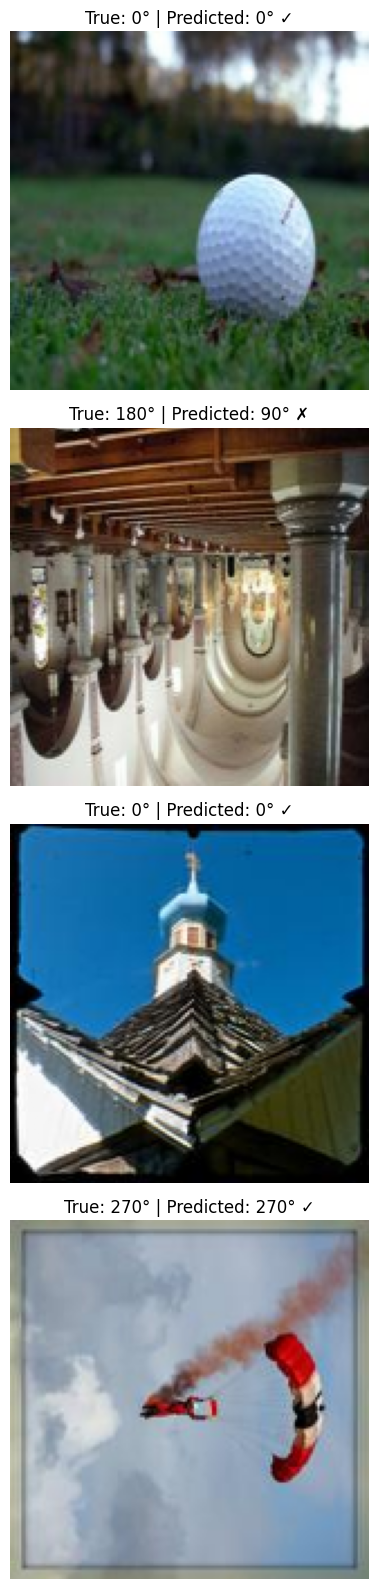

Accuracy on test images: 89.18%


In [28]:
# When running with a resnet101 and 100 epochs
# MODEL_PATH = './rotation_model_imagenette.pth'
test_model = resnet101(num_classes=4)  # Use ResNet50 to match the saved model
test_model = test_model.to(device)

# Load saved state
test_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
test_model.eval()

# Create test dataloader with a small batch size for visualization
test_loader = DataLoader(dataset_rot, batch_size=4, shuffle=True)

# Get a batch of test images
dataiter = iter(test_loader)
images, rotated_images, rotation_labels, class_labels = next(dataiter)

# Make predictions
rotated_images_device = rotated_images.to(device)
with torch.no_grad():
    outputs = test_model(rotated_images_device)
    _, predicted = torch.max(outputs, 1)

# Display results
rot_names = ['0°', '90°', '180°', '270°']
fig, axes = plt.subplots(4, 1, figsize=(10, 16))

for i in range(4):
    # Display rotated image with true and predicted labels
    rotated_img = rotated_images[i].permute(1, 2, 0).cpu().numpy()
    axes[i].imshow(rotated_img)
    true_label = rotation_labels[i].item()
    pred_label = predicted[i].item()
    correct = "✓" if true_label == pred_label else "✗"
    axes[i].set_title(f"True: {rot_names[true_label]} | Predicted: {rot_names[pred_label]} {correct}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Calculate accuracy on a larger test set
correct = 0
total = 0
with torch.no_grad():
    for images, rotated_images, rotation_labels, _ in test_loader:
        rotated_images = rotated_images.to(device)
        rotation_labels = rotation_labels.to(device)
        outputs = test_model(rotated_images)
        _, predicted = torch.max(outputs, 1)
        total += rotation_labels.size(0)
        correct += (predicted == rotation_labels).sum().item()

print(f"Accuracy on test images: {100 * correct / total:.2f}%")

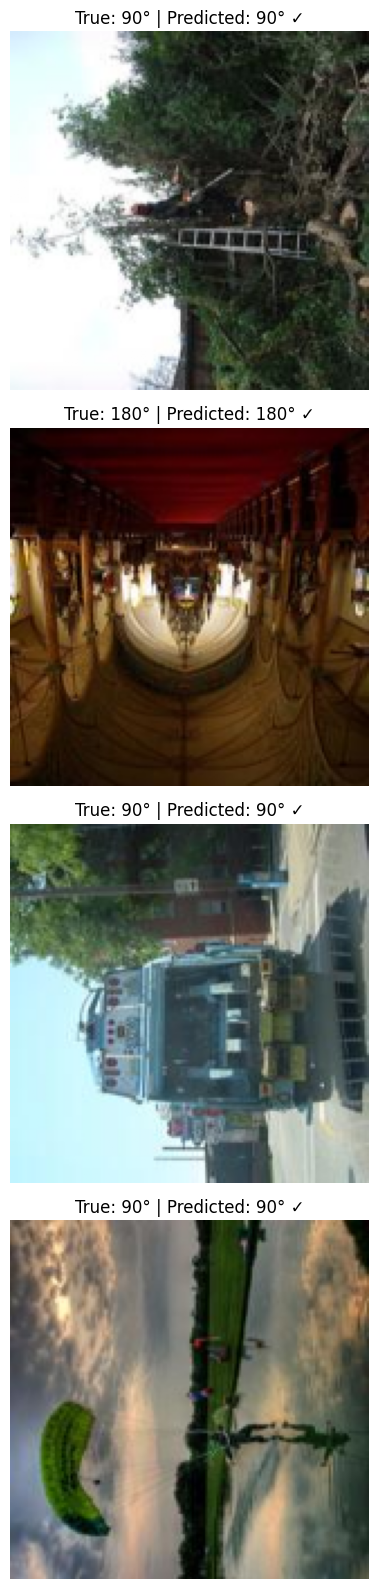

Accuracy on test images: 88.21%


In [6]:
# When running with a resnet18
MODEL_PATH = './rotation_model_imagenette_18_45.pth'
test_model = resnet18(num_classes=4)  # Use ResNet50 to match the saved model
test_model = test_model.to(device)


# Load saved state
test_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
test_model.eval()

# Create test dataloader with a small batch size for visualization
test_loader = DataLoader(dataset_rot, batch_size=4, shuffle=True)

# Get a batch of test images
dataiter = iter(test_loader)
images, rotated_images, rotation_labels, class_labels = next(dataiter)

# Make predictions
rotated_images_device = rotated_images.to(device)
with torch.no_grad():
    outputs = test_model(rotated_images_device)
    _, predicted = torch.max(outputs, 1)

# Display results
rot_names = ['0°', '90°', '180°', '270°']
fig, axes = plt.subplots(4, 1, figsize=(10, 16))

for i in range(4):
    # Display rotated image with true and predicted labels
    rotated_img = rotated_images[i].permute(1, 2, 0).cpu().numpy()
    axes[i].imshow(rotated_img)
    true_label = rotation_labels[i].item()
    pred_label = predicted[i].item()
    correct = "✓" if true_label == pred_label else "✗"
    axes[i].set_title(f"True: {rot_names[true_label]} | Predicted: {rot_names[pred_label]} {correct}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Calculate accuracy on a larger test set
correct = 0
total = 0
with torch.no_grad():
    for images, rotated_images, rotation_labels, _ in test_loader:
        rotated_images = rotated_images.to(device)
        rotation_labels = rotation_labels.to(device)
        outputs = test_model(rotated_images)
        _, predicted = torch.max(outputs, 1)
        total += rotation_labels.size(0)
        correct += (predicted == rotation_labels).sum().item()

print(f"Accuracy on test images: {100 * correct / total:.2f}%")

In [7]:
# === Modified Second-to-Last Cell (Setup: Load Rotation Weights for Classification) ===
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.models import resnet18 
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import pandas as pd
from PIL import Image
import os
import time


class NoisyImagenetteDataset(Dataset):
    def __init__(self, csv_file, data_dir, transform=None,
                 label_column='noisy_labels_0'):
        self.data = pd.read_csv(csv_file)
        self.data_dir = data_dir
        self.transform = transform
        self.label_column = label_column

        self.classes = self.data[self.label_column].unique()
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        print(f"Found {len(self.classes)} classes.")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_rel_path = row['path']
        img_path = os.path.join(self.data_dir, *img_rel_path.split('/'))
        try:
            image = Image.open(img_path).convert("RGB")
        except FileNotFoundError:
            print(f"Error: Image not found at {img_path}")
            return None, -1 

        label_name = row[self.label_column]
        label_idx = self.class_to_idx[label_name]
        label = torch.tensor(label_idx).long()

        if self.transform:
            image = self.transform(image)

        return image, label

# --- Paths and Device ---
csv_path = 'imagenette2-160/noisy_imagenette.csv'
data_dir = os.path.dirname(csv_path)
ROTATION_MODEL_PATH = './rotation_model_imagenette_18_45.pth' 
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.mps.is_available() else 'cpu'
print(f"Using device: {device}")

# Transformations
transform_clf = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

try:
    full_clf_dataset = NoisyImagenetteDataset(csv_file=csv_path, data_dir=data_dir, transform=transform_clf)
    num_classes = len(full_clf_dataset.classes)
    print(f"Dataset loaded successfully with {num_classes} classes.")

    num_samples = len(full_clf_dataset)
    train_size = int(0.9 * num_samples)
    val_size = num_samples - train_size
    train_dataset_clf, val_dataset_clf = random_split(full_clf_dataset, [train_size, val_size])

    train_loader_clf = DataLoader(train_dataset_clf, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
    val_loader_clf = DataLoader(val_dataset_clf, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)
    print(f"Training samples: {len(train_dataset_clf)}, Validation samples: {len(val_dataset_clf)}")

    print("Setting up classification model...")

    net_clf = resnet18(num_classes=num_classes)

    if os.path.exists(ROTATION_MODEL_PATH):
        rotation_state_dict = torch.load(ROTATION_MODEL_PATH, map_location=device)

        rotation_state_dict.pop('fc.weight', None)
        rotation_state_dict.pop('fc.bias', None)

        load_result = net_clf.load_state_dict(rotation_state_dict, strict=False)
        print(f"  Missing keys: {load_result.missing_keys}")
        print(f"  Unexpected keys: {load_result.unexpected_keys}")

    else:
        print(f"Warning: Rotation model file not found at {ROTATION_MODEL_PATH}. Initializing model from scratch.")


    net_clf = net_clf.to(device)

    # --- Loss, Optimizer, Scheduler ---
    criterion_clf = nn.CrossEntropyLoss()
    optimizer_clf = optim.SGD(net_clf.parameters(), lr=0.001, momentum=0.9, weight_decay=5e-4)
    scheduler_clf = optim.lr_scheduler.StepLR(optimizer_clf, step_size=7, gamma=0.1)

    print("Setup for Imagenette classification complete.")

except FileNotFoundError:
    print(f"Error: CSV file not found at {csv_path} or Model file not found at {ROTATION_MODEL_PATH}. Please check paths.")
except Exception as e:
    print(f"An error occurred during setup: {e}")



Using device: mps
Found 10 classes.
Dataset loaded successfully with 10 classes.
Training samples: 12054, Validation samples: 1340
Setting up classification model...
  Missing keys: ['fc.weight', 'fc.bias']
  Unexpected keys: []
Setup for Imagenette classification complete.


In [8]:
def train_classification(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=10):
    best_acc = 0.0
    model.to(device)

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        start_time = time.time()

        for batch_idx, (images, labels) in enumerate(train_loader):
            if images is None:
                print(f"Skipping batch {batch_idx} due to loading error.")
                continue

            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_acc = (100 * correct / total) if total > 0 else 0
        epoch_loss = running_loss / len(train_loader) if len(train_loader) > 0 else 0
        
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {epoch_loss:.4f}, Train Acc: {train_acc:.2f}%, Time: {time.time() - start_time:.2f}s')
        # Save model if validation accuracy improves
        if epoch % 5 == 0:
            save_path = f'./imagenette_classification_{epoch}.pth'
            torch.save(model.state_dict(), save_path)

    print(f'Finished Training')
    return model 


In [9]:
# --- Call the Training Function ---
if 'net_clf' in locals() and 'train_loader_clf' in locals():
    print("Starting Imagenette classification training...")
    # Adjust num_epochs as needed
    trained_net_clf = train_classification(
        net_clf,
        train_loader_clf,
        val_loader_clf,
        criterion_clf,
        optimizer_clf,
        scheduler_clf,
        num_epochs=30
    )
    print("Imagenette classification training finished.")

    final_model_path = './imagenette_classification_final.pth'
    torch.save(trained_net_clf.state_dict(), final_model_path)
    print(f"Final model saved to {final_model_path}")
else:
    print("Skipping training call because setup cell did not complete successfully.")


Starting Imagenette classification training...
Epoch [1/30], Loss: 2.1592, Train Acc: 30.15%, Time: 25.45s
Epoch [2/30], Loss: 1.6366, Train Acc: 49.73%, Time: 25.24s
Epoch [3/30], Loss: 1.2316, Train Acc: 61.87%, Time: 25.09s
Epoch [4/30], Loss: 1.0003, Train Acc: 68.75%, Time: 25.23s
Epoch [5/30], Loss: 0.8364, Train Acc: 73.45%, Time: 24.80s
Epoch [6/30], Loss: 0.7211, Train Acc: 77.33%, Time: 25.51s
Epoch [7/30], Loss: 0.6185, Train Acc: 80.91%, Time: 24.52s
Epoch [8/30], Loss: 0.5192, Train Acc: 83.85%, Time: 24.63s
Epoch [9/30], Loss: 0.4303, Train Acc: 87.24%, Time: 24.67s
Epoch [10/30], Loss: 0.3433, Train Acc: 90.09%, Time: 24.65s
Epoch [11/30], Loss: 0.2682, Train Acc: 92.83%, Time: 24.64s
Epoch [12/30], Loss: 0.1917, Train Acc: 95.63%, Time: 24.70s
Epoch [13/30], Loss: 0.1360, Train Acc: 97.38%, Time: 24.64s
Epoch [14/30], Loss: 0.0953, Train Acc: 98.55%, Time: 31.87s
Epoch [15/30], Loss: 0.0726, Train Acc: 98.99%, Time: 26.09s
Epoch [16/30], Loss: 0.0516, Train Acc: 99.57%,

In [10]:
# === Cell for Validation/Testing After Training ===
import torch
import torch.nn as nn
from torchvision.models import resnet18 
from torch.utils.data import DataLoader
import os
import time

def evaluate_model(model, data_loader, criterion, device):
    """Evaluates the model on the given data loader."""
    model.eval() 
    running_loss = 0.0
    correct = 0
    total = 0
    start_time = time.time()

    with torch.no_grad():
        for images, labels in data_loader:
            if images is None:
                print(f"Skipping evaluation batch due to loading error.")
                continue

            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    eval_time = time.time() - start_time
    # Prevent division by zero
    avg_loss = running_loss / len(data_loader) if len(data_loader) > 0 else 0
    accuracy = 100 * correct / total if total > 0 else 0

    print(f'Evaluation complete in {eval_time:.2f}s')
    return avg_loss, accuracy

MODEL_TO_EVALUATE_PATH = './imagenette_classification_final.pth'

if 'net_clf' not in locals() or 'val_loader_clf' not in locals() or 'criterion_clf' not in locals():
     print("Error: Setup variables (model, dataloader, criterion) not found. Run the setup cell first.")
elif not os.path.exists(MODEL_TO_EVALUATE_PATH):
    print(f"Error: Model file not found at {MODEL_TO_EVALUATE_PATH}. Ensure training completed and saved the model.")
else:
    print(f"Loading model for evaluation from: {MODEL_TO_EVALUATE_PATH}")
    if 'num_classes' not in locals():
        print("Error: num_classes variable not found. Cannot initialize model.")
    else:
        evaluation_model = resnet18(num_classes=num_classes) 
        try:

            evaluation_model.load_state_dict(torch.load(MODEL_TO_EVALUATE_PATH, map_location=device))
            evaluation_model.to(device) 
            print("Model loaded successfully.")

            print("\nEvaluating on Validation Set...")
            val_loss, val_accuracy = evaluate_model(
                evaluation_model,
                val_loader_clf,
                criterion_clf,
                device
            )

            print(f'\nValidation Loss: {val_loss:.4f}')
            print(f'Validation Accuracy: {val_accuracy:.2f}%')

        except Exception as e:
            print(f"An error occurred during model loading or evaluation: {e}")



Loading model for evaluation from: ./imagenette_classification_final.pth
Model loaded successfully.

Evaluating on Validation Set...
Evaluation complete in 1.23s

Validation Loss: 0.8300
Validation Accuracy: 78.73%
